# BiGRU Sarcasm Detection

End-to-end pipeline: data loading, robust text cleaning, mode-specific vocabulary + GloVe initialization, and sequential training of BiGRU / BiGRU+Attention on both `context` and `comment_only` inputs.


In [1]:
%pip install -q scikit-learn tqdm seaborn torch

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import random
import warnings
from collections import Counter

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)
from tqdm.auto import tqdm

from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
import json
import re

# Configuration and Reproducibility


In [3]:
INPUT_MODE = "context"
INPUT_MODES = ["context", "comment_only"]
VAL_RATIO = 0.10
SEED = 42
SAMPLE_SIZE = None

BATCH_SIZE = 256
EMBED_DIM = 300


def seed_everything(seed: int = 42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False

    try:
        torch.use_deterministic_algorithms(True)
    except Exception as e:
        print(f"Deterministic algorithm warning: {e}")


seed_everything(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"Default helper mode: {INPUT_MODE}")
print(f"Training modes: {', '.join(INPUT_MODES)}")

# Paths adjusted for this workspace
TRAIN_PATH = "/kaggle/input/datasets/pramatharao/nlp-course-project-ds/train-balanced.csv"
TEST_PATH = "/kaggle/input/datasets/pramatharao/nlp-course-project-ds/test-balanced.csv"
GLOVE_PATH = "/kaggle/input/datasets/ar3snd/glove-embeddings/wiki_giga_2024_300_MFT20_vectors_seed_2024_alpha_0.75_eta_0.05_combined.txt"

assert os.path.exists(TRAIN_PATH), f"Missing file: {TRAIN_PATH}"
assert os.path.exists(TEST_PATH), f"Missing file: {TEST_PATH}"
assert os.path.exists(GLOVE_PATH), f"Missing file: {GLOVE_PATH}"

Using device: cuda
Default helper mode: context
Training modes: context, comment_only


In [4]:
# =============================================================================
# Data loading and split (aligned with file1)
# =============================================================================

def load_and_clean(path: str, sample_size: int | None = None) -> pd.DataFrame:
    """Load CSV, drop nulls in 'comment', optionally sub-sample."""
    df = pd.read_csv(path, sep='\t')
    df.dropna(subset=["comment"], inplace=True)
    df["comment"] = df["comment"].astype(str).str.strip()
    df = df[df["comment"] != ""]
    # parent_comment may be missing in some rows — fill with empty string
    if "parent_comment" not in df.columns:
        df["parent_comment"] = ""
    df["parent_comment"] = df["parent_comment"].fillna("").astype(str)
    if sample_size is not None:
        df = df.sample(n=sample_size, random_state=SEED).reset_index(drop=True)
    print(f"Loaded {len(df):,} rows  |  label balance:\n{df['label'].value_counts()}\n")
    return df


In [5]:
def split_train_val(
    df: pd.DataFrame,
    val_ratio: float = VAL_RATIO,
    seed: int = SEED,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Stratified train / val split."""
    
    train, val = train_test_split(
        df,
        test_size=val_ratio,
        stratify=df["label"],
        random_state=seed
    )

    for split, name in [(train, "train"), (val, "val")]:
        pos = split["label"].mean()
        print(f"{name:5s}: {len(split):>7,} rows | sarcasm = {pos:.1%}")
    print()

    return train.reset_index(drop=True), val.reset_index(drop=True)


In [6]:
raw_df = load_and_clean(TRAIN_PATH, sample_size=SAMPLE_SIZE)
raw_train_df, raw_val_df = split_train_val(raw_df)

raw_test_df = load_and_clean(TEST_PATH, sample_size=None)

# Compatibility aliases for the EDA section
train_df = raw_train_df
val_df = raw_val_df
test_df = raw_test_df

print(f"Train size: {len(raw_train_df):,}")
print(f"Val size:   {len(raw_val_df):,}")
print(f"Test size:  {len(raw_test_df):,}")

Loaded 1,010,771 rows  |  label balance:
label
0    505403
1    505368
Name: count, dtype: int64

train: 909,693 rows | sarcasm = 50.0%
val  : 101,078 rows | sarcasm = 50.0%

Loaded 251,592 rows  |  label balance:
label
0    125797
1    125795
Name: count, dtype: int64

Train size: 909,693
Val size:   101,078
Test size:  251,592


# Quick EDA


In [7]:
# def plot_log_length_distribution(df, title):
#     lengths = df["comment"].astype(str).str.len().clip(lower=1)
#     plt.figure(figsize=(7, 4))
#     plt.hist(np.log10(lengths), bins=50, alpha=0.8)
#     plt.title(title)
#     plt.xlabel("log10(comment length)")
#     plt.ylabel("count")
#     plt.show()

# plot_log_length_distribution(train_df, "Train Comment Length Distribution")
# print(train_df.head(3))

In [8]:
# print("Example sarcastic comments:")
# print(train_df.loc[train_df["label"] == 1, "comment"].head(3).to_string(index=False))

# print("\nExample non-sarcastic comments:")
# print(train_df.loc[train_df["label"] == 0, "comment"].head(3).to_string(index=False))

In [9]:
# label_counts = train_df["label"].value_counts().sort_index()
# plt.figure(figsize=(5, 4))
# plt.bar(["non-sarcastic (0)", "sarcastic (1)"], label_counts.values)
# plt.title("Training Label Distribution")
# plt.ylabel("count")
# plt.show()

# Text Cleaning, Tokenization, and Dataset Building


## 1. Input Text Builder


In [10]:
def build_text(comment: str, parent: str, mode: str = "context") -> str:
    comment = str(comment).strip()
    if mode == "comment_only":
        return comment
    if mode == "context":
        parent = str(parent).strip() if pd.notna(parent) else ""
        return f"{parent} [SEP] {comment}" if parent else comment
    raise ValueError("Unknown input mode. Choose 'comment_only' or 'context'.")

In [11]:
def preprocess_df(df: pd.DataFrame, input_mode: str = "context") -> pd.DataFrame:
    out = df.copy()
    out = out.dropna(subset=["comment"])
    out["comment"] = out["comment"].astype(str).str.strip()
    out = out[out["comment"] != ""]
    if "parent_comment" not in out.columns:
        out["parent_comment"] = ""
    out["parent_comment"] = out["parent_comment"].fillna("").astype(str)
    out["label"] = out["label"].astype(int)

    out["model_text"] = out.apply(
        lambda r: build_text(r["comment"], r["parent_comment"], input_mode),
        axis=1,
    )
    out = out[out["model_text"].str.len() > 0]
    out = out.reset_index(drop=True)
    return out

In [12]:
print("Raw splits loaded and ready for mode-specific preprocessing.")
print(f"Raw train rows: {len(raw_train_df):,}")
print(f"Raw val rows:   {len(raw_val_df):,}")
print(f"Raw test rows:  {len(raw_test_df):,}")

Raw splits loaded and ready for mode-specific preprocessing.
Raw train rows: 909,693
Raw val rows:   101,078
Raw test rows:  251,592


## 2. Tokenization + Vocabulary


In [13]:
def tokenize(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text.split()


MAX_VOCAB_SIZE = 120_000
MIN_FREQ = 2
MAX_LEN = 100
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"


def build_vocab(texts):
    counter = Counter()
    for text in tqdm(texts, desc="Building token frequency"):
        counter.update(tokenize(text))

    vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
    for token, freq in counter.most_common(MAX_VOCAB_SIZE):
        if freq < MIN_FREQ:
            break
        if token not in vocab:
            vocab[token] = len(vocab)

    return vocab

In [14]:
def numericalize(text: str, vocab_dict, unk_idx: int, max_len: int = MAX_LEN):
    ids = [vocab_dict.get(tok, unk_idx) for tok in tokenize(text)]
    if len(ids) == 0:
        ids = [unk_idx]
    if len(ids) > max_len:
        ids = ids[:max_len]
    return torch.tensor(ids, dtype=torch.long)

In [15]:
class SarcasmDataset(Dataset):
    def __init__(self, df, text_column="model_text", label_column="label"):
        self.df = df.reset_index(drop=True).copy()
        self.texts = self.df[text_column].tolist()
        self.labels = self.df[label_column].astype(int).tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        text = self.texts[idx]
        y = torch.tensor(float(self.labels[idx]), dtype=torch.float32)
        return text, y

## 3. GLoVe Embedding Matrix


In [16]:
def build_embedding_matrix(vocab, glove_path: str, embed_dim: int, pad_idx: int):
    embedding_matrix = np.random.normal(loc=0.0, scale=0.1, size=(len(vocab), embed_dim)).astype(np.float32)
    embedding_matrix[pad_idx] = 0.0

    hits = 0
    with open(glove_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in tqdm(f, desc="Loading matching GloVe vectors"):
            parts = line.rstrip().split(" ")
            if len(parts) != embed_dim + 1:
                continue
            word = parts[0]
            if word in vocab:
                vec = np.asarray(parts[1:], dtype=np.float32)
                embedding_matrix[vocab[word]] = vec
                hits += 1

    coverage = hits / max(1, len(vocab) - 2)
    print(f"Matched vectors: {hits:,}")
    print(f"Coverage: {coverage:.2%}")

    return torch.tensor(embedding_matrix, dtype=torch.float32)

## 4. Bundle all the datasets


In [17]:
def make_collate_batch(vocab_dict, pad_idx: int, unk_idx: int):
    def collate_batch(batch):
        xs, ys = zip(*batch)
        xs = [numericalize(text, vocab_dict, unk_idx=unk_idx) for text in xs]
        lengths = torch.tensor([len(x) for x in xs], dtype=torch.long)
        xs_padded = pad_sequence(xs, batch_first=True, padding_value=pad_idx)
        ys = torch.stack(ys)
        return xs_padded, lengths, ys

    return collate_batch

In [18]:
def build_mode_bundle(input_mode: str, raw_train_df, raw_val_df, raw_test_df):
    train_df = preprocess_df(raw_train_df, input_mode=input_mode)
    val_df = preprocess_df(raw_val_df, input_mode=input_mode)
    test_df = preprocess_df(raw_test_df, input_mode=input_mode)

    print(f"[{input_mode}] After preprocessing -> Train: {len(train_df):,}, Val: {len(val_df):,}, Test: {len(test_df):,}")

    vocab = build_vocab(train_df["model_text"])
    pad_idx = vocab[PAD_TOKEN]
    unk_idx = vocab[UNK_TOKEN]

    print(f"[{input_mode}] Vocab size: {len(vocab):,}")

    train_ds = SarcasmDataset(train_df)
    val_ds = SarcasmDataset(val_df)
    test_ds = SarcasmDataset(test_df)

    collate_fn = make_collate_batch(vocab, pad_idx=pad_idx, unk_idx=unk_idx)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

    embedding_matrix = build_embedding_matrix(vocab, GLOVE_PATH, EMBED_DIM, pad_idx)

    return {
        "input_mode": input_mode,
        "train_df": train_df,
        "val_df": val_df,
        "test_df": test_df,
        "vocab": vocab,
        "pad_idx": pad_idx,
        "unk_idx": unk_idx,
        "train_ds": train_ds,
        "val_ds": val_ds,
        "test_ds": test_ds,
        "train_loader": train_loader,
        "val_loader": val_loader,
        "test_loader": test_loader,
        "embedding_matrix": embedding_matrix,
    }

# BiGRU Model Training

Sequential training for each input mode with per-mode result folders.


In [19]:
ARTIFACTS_ROOT = Path("model_artifacts")
ARTIFACTS_ROOT.mkdir(parents=True, exist_ok=True)


def model_slug(model_name: str) -> str:
    slug = model_name.lower().replace("+", "_plus_").replace(" ", "_")
    return "".join(ch for ch in slug if ch.isalnum() or ch in {"_", "-"})


def prepare_model_dir(input_mode: str, model_name: str) -> Path:
    model_dir = ARTIFACTS_ROOT / model_slug(input_mode) / model_slug(model_name)
    model_dir.mkdir(parents=True, exist_ok=True)
    return model_dir


def save_json(data: dict, file_path: Path):
    with open(file_path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2, ensure_ascii=True)

In [20]:
class BiGRUClassifier(nn.Module):
    def __init__(self, embedding_weights, pad_idx: int, hidden_size=128, num_layers=2, dropout=0.3):
        super().__init__()
        vocab_size, emb_dim = embedding_weights.shape

        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.embedding.weight.data.copy_(embedding_weights)

        self.gru = nn.GRU(
            input_size=emb_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        feature_dim = hidden_size * 4 

        self.classifier = nn.Sequential(
            nn.Linear(feature_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x, lengths):
        emb = self.embedding(x)

        packed = pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, _ = self.gru(packed)
        out, _ = pad_packed_sequence(packed_out, batch_first=True)

        # Mask
        max_len = out.size(1)
        mask = torch.arange(max_len, device=lengths.device).unsqueeze(0) < lengths.unsqueeze(1)

        # Max Pooling
        out_masked = out.masked_fill(~mask.unsqueeze(-1), float("-inf"))
        max_pool, _ = torch.max(out_masked, dim=1)

        # Avg Pooling
        out_sum = torch.sum(out * mask.unsqueeze(-1), dim=1)
        avg_pool = out_sum / lengths.unsqueeze(1)

        features = torch.cat([max_pool, avg_pool], dim=1)

        logits = self.classifier(features).squeeze(1)
        return logits

In [21]:
class BiGRUAttentionClassifier(nn.Module):
    def __init__(self, embedding_weights, pad_idx: int, hidden_size=128, num_layers=2, dropout=0.3):
        super().__init__()
        vocab_size, emb_dim = embedding_weights.shape

        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.embedding.weight.data.copy_(embedding_weights)

        self.gru = nn.GRU(
            input_size=emb_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.attention = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1, bias=False),
        )

        feature_dim = hidden_size * 4 

        self.classifier = nn.Sequential(
            nn.Linear(feature_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x, lengths):
        emb = self.embedding(x)

        packed = pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, _ = self.gru(packed)
        out, _ = pad_packed_sequence(packed_out, batch_first=True)

        max_len = out.size(1)
        mask = torch.arange(max_len, device=lengths.device).unsqueeze(0) < lengths.unsqueeze(1)

        # Attention
        attn_scores = self.attention(out).squeeze(-1)
        attn_scores = attn_scores.masked_fill(~mask, float("-inf"))
        attn_weights = torch.softmax(attn_scores, dim=1).unsqueeze(-1)

        context = torch.sum(out * attn_weights, dim=1)

        # Max Pool
        out_masked = out.masked_fill(~mask.unsqueeze(-1), float("-inf"))
        max_pool, _ = torch.max(out_masked, dim=1)


        features = torch.cat([context, max_pool], dim=1)

        logits = self.classifier(features).squeeze(1)
        return logits

In [22]:
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    return {"acc": acc, "precision": p, "recall": r, "f1": f1}

In [23]:
def run_epoch(model, loader, optimizer=None, criterion=None, device=DEVICE):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    losses = []
    all_probs = []
    all_labels = []

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for x, lengths, y in tqdm(loader, leave=False):
            x = x.to(device)
            lengths = lengths.to(device)
            y = y.to(device)

            logits = model(x, lengths)
            loss = criterion(logits, y)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            probs = torch.sigmoid(logits)
            losses.append(loss.item())
            all_probs.append(probs.detach().cpu().numpy())
            all_labels.append(y.detach().cpu().numpy())

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels).astype(int)
    metrics = compute_metrics(all_labels, all_probs)
    metrics["loss"] = float(np.mean(losses)) if losses else float("nan")
    return metrics

In [24]:
def collect_predictions(model, loader, device):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for x, lengths, y in tqdm(loader, leave=False):
            x = x.to(device)
            lengths = lengths.to(device)
            logits = model(x, lengths)
            probs = torch.sigmoid(logits).detach().cpu().numpy()
            all_probs.append(probs)
            all_labels.append(y.numpy())

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels).astype(int)
    return all_labels, all_probs

In [25]:
import time


def train_model(input_mode, model_name, model_cls, device, bundle):
    seed_everything(SEED)

    model_dir = prepare_model_dir(input_mode, model_name)
    best_model_path = model_dir / "best_model.pt"
    last_model_path = model_dir / "last_model.pt"

    if device.type == "cuda":
        torch.cuda.set_device(device.index if device.index is not None else 0)

    train_loader = bundle["train_loader"]
    val_loader = bundle["val_loader"]
    train_for_weight = bundle["train_df"]

    pos = train_for_weight["label"].sum()
    neg = len(train_for_weight) - pos
    pos_weight = torch.tensor([neg / max(pos, 1)], dtype=torch.float32, device=device)

    model = model_cls(bundle["embedding_matrix"], pad_idx=bundle["pad_idx"], hidden_size=128, num_layers=2, dropout=0.3).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=1)

    EPOCHS = 15
    PATIENCE = 20

    history = []
    best_state = None
    best_val_f1 = -1.0
    best_epoch = 0
    wait = 0

    save_json(
        {
            "input_mode": input_mode,
            "model_name": model_name,
            "model_dir": str(model_dir),
            "device": str(device),
            "batch_size": BATCH_SIZE,
            "epochs": EPOCHS,
            "patience": PATIENCE,
            "optimizer": "AdamW",
            "learning_rate": 2e-3,
            "weight_decay": 1e-4,
            "loss": "BCEWithLogitsLoss(pos_weight)",
            "scheduler": "ReduceLROnPlateau(mode=max,factor=0.5,patience=1)",
        },
        model_dir / "training_config.json",
    )

    print(f"[{input_mode} | {model_name}] starting on {device}")

    for epoch in range(1, EPOCHS + 1):
        start = time.time()
        train_metrics = run_epoch(model, train_loader, optimizer=optimizer, criterion=criterion, device=device)
        val_metrics = run_epoch(model, val_loader, optimizer=None, criterion=criterion, device=device)

        scheduler.step(val_metrics["f1"])

        row = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_acc": train_metrics["acc"],
            "train_f1": train_metrics["f1"],
            "val_loss": val_metrics["loss"],
            "val_acc": val_metrics["acc"],
            "val_f1": val_metrics["f1"],
        }

        history.append(row)
        end = time.time()
        seconds = end-start
        minutes = seconds // 60
        hours = minutes // 60
        seconds %= 60
        minutes %= 60

        print(
            f"[{input_mode} | {model_name}] Epoch {epoch:02d} | "
            f"Train loss {row['train_loss']:.4f}, acc {row['train_acc']:.4f}, f1 {row['train_f1']:.4f} | "
            f"Val loss {row['val_loss']:.4f}, acc {row['val_acc']:.4f}, f1 {row['val_f1']:.4f} | "
            f"Time taken: {hours}:{minutes}:{seconds}"
        )

        if val_metrics["f1"] > best_val_f1:
            best_val_f1 = val_metrics["f1"]
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0

            torch.save(
                {
                    "input_mode": input_mode,
                    "model_name": model_name,
                    "epoch": epoch,
                    "val_f1": float(val_metrics["f1"]),
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "scheduler_state_dict": scheduler.state_dict(),
                },
                best_model_path,
            )
        else:
            wait += 1
            if wait >= PATIENCE:
                print(f"[{input_mode} | {model_name}] Early stopping triggered at epoch {epoch}.")
                break

    torch.save(
        {
            "input_mode": input_mode,
            "model_name": model_name,
            "epoch": history[-1]["epoch"] if history else 0,
            "val_f1": float(history[-1]["val_f1"]) if history else float("nan"),
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
        },
        last_model_path,
    )

    if best_state is not None:
        model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)
    history_df.to_csv(model_dir / "history.csv", index=False)

    save_json(
        {
            "input_mode": input_mode,
            "model_name": model_name,
            "best_val_f1": float(best_val_f1),
            "best_epoch": int(best_epoch),
            "epochs_ran": int(len(history_df)),
            "best_model_path": str(best_model_path),
            "last_model_path": str(last_model_path),
        },
        model_dir / "training_summary.json",
    )

    return {
        "input_mode": input_mode,
        "name": model_name,
        "model": model,
        "device": device,
        "criterion": criterion,
        "history": history_df,
        "best_val_f1": best_val_f1,
        "best_epoch": best_epoch,
        "model_dir": str(model_dir),
        "best_model_path": str(best_model_path),
        "last_model_path": str(last_model_path),
        "vocab": bundle["vocab"],
        "pad_idx": bundle["pad_idx"],
        "unk_idx": bundle["unk_idx"],
        "text_column": "model_text",
    }

In [26]:
cuda_count = torch.cuda.device_count() if torch.cuda.is_available() else 0
bi_gru_device = torch.device("cuda:0" if cuda_count >= 1 else "cpu")
attention_device = torch.device("cuda:1" if cuda_count >= 2 else ("cuda:0" if cuda_count >= 1 else "cpu"))

In [27]:
training_results = {}
mode_bundles = {}

model_specs = [
    ("BiGRU", BiGRUClassifier, bi_gru_device),
    ("BiGRU+Attention", BiGRUAttentionClassifier, attention_device),
]

for input_mode in INPUT_MODES:
    print(f"\n=== Starting input mode: {input_mode} ===")
    bundle = build_mode_bundle(input_mode, raw_train_df, raw_val_df, raw_test_df)
    mode_bundles[input_mode] = bundle
    training_results[input_mode] = {}

    for model_name, model_cls, device in model_specs:
        print(f"\n--- Training model: {model_name} on {device} ---")
        training_results[input_mode][model_name] = train_model(input_mode, model_name, model_cls, device, bundle)


=== Starting input mode: context ===
[context] After preprocessing -> Train: 909,693, Val: 101,078, Test: 251,592


Building token frequency:   0%|          | 0/909693 [00:00<?, ?it/s]

[context] Vocab size: 120,002


Loading matching GloVe vectors: 0it [00:00, ?it/s]

Matched vectors: 98,047
Coverage: 81.71%

--- Training model: BiGRU on cuda:0 ---
[context | BiGRU] starting on cuda:0


...

  0%|          | 0/395 [00:00<?, ?it/s]

[comment_only | BiGRU+Attention] Epoch 14 | Train loss 0.1422, acc 0.9376, f1 0.9368 | Val loss 1.8227, acc 0.7070, f1 0.6985 | Time taken: 0.0:3.0:0.34024858474731445


  0%|          | 0/3554 [00:00<?, ?it/s]

  0%|          | 0/395 [00:00<?, ?it/s]

[comment_only | BiGRU+Attention] Epoch 15 | Train loss 0.1394, acc 0.9387, f1 0.9379 | Val loss 1.8929, acc 0.7066, f1 0.6987 | Time taken: 0.0:3.0:0.8151512145996094


In [28]:
history_rows = []
for input_mode, model_runs in training_results.items():
    for model_name, result in model_runs.items():
        history_rows.append(result["history"].assign(input_mode=input_mode, model=model_name))

history_summary = pd.concat(history_rows, ignore_index=True, sort=False)
display(history_summary)

history_summary.to_csv(ARTIFACTS_ROOT / "history_summary.csv", index=False)

,epoch,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1,input_mode,model
0,1,0.552216,0.715373,0.701162,0.524854,0.734304,0.714310,context,BiGRU
1,2,0.479878,0.768126,0.763369,0.530400,0.735155,0.724905,context,BiGRU
2,3,0.406649,0.811446,0.809066,0.555834,0.722541,0.711159,context,BiGRU
3,4,0.341722,0.845092,0.843337,0.609905,0.714132,0.713215,context,BiGRU
4,5,0.255907,0.886812,0.885826,0.787491,0.705910,0.698874,context,BiGRU
5,6,0.200287,0.912657,0.911859,0.916368,0.700380,0.692984,context,BiGRU
6,7,0.144311,0.937812,0.937335,1.260314,0.698114,0.687817,context,BiGRU
7,8,0.114738,0.950385,0.950010,1.546321,0.693900,0.690427,context,BiGRU
8,9,0.087595,0.962404,0.962167,1.933475,0.692139,0.686721,context,BiGRU
9,10,0.074853,0.967889,0.967703,2.229585,0.689873,0.684926,context,BiGRU


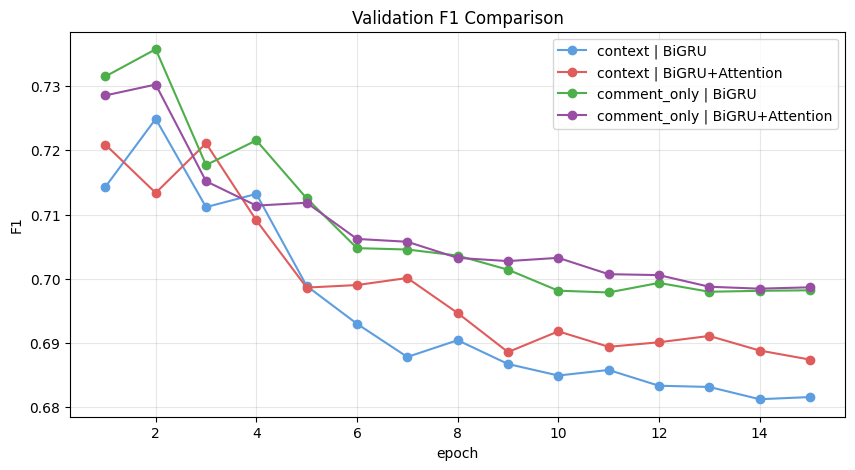

Artifacts for context | BiGRU: model_artifacts/context/bigru
Artifacts for context | BiGRU+Attention: model_artifacts/context/bigru_plus_attention
Artifacts for comment_only | BiGRU: model_artifacts/comment_only/bigru
Artifacts for comment_only | BiGRU+Attention: model_artifacts/comment_only/bigru_plus_attention


In [29]:
plt.figure(figsize=(10, 5))
palette = {
    ("context", "BiGRU"): "#5c9ee0",
    ("context", "BiGRU+Attention"): "#e05c5c",
    ("comment_only", "BiGRU"): "#4daf4a",
    ("comment_only", "BiGRU+Attention"): "#984ea3",
}

for input_mode, model_runs in training_results.items():
    for model_name, result in model_runs.items():
        history_df = result["history"]
        color = palette.get((input_mode, model_name), None)
        plt.plot(
            history_df["epoch"],
            history_df["val_f1"],
            marker="o",
            label=f"{input_mode} | {model_name}",
            color=color,
        )

plt.xlabel("epoch")
plt.ylabel("F1")
plt.title("Validation F1 Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

for input_mode, model_runs in training_results.items():
    for model_name, result in model_runs.items():
        print(f"Artifacts for {input_mode} | {model_name}: {result['model_dir']}")

# Final Test Evaluation

Evaluation is performed separately for each mode and model combination.


In [30]:
def evaluate_model(model_name, model_result, loader, output_dir=None):
    seed_everything(SEED)
    model = model_result["model"]
    device = model_result["device"]
    criterion = model_result["criterion"]

    all_labels, all_probs = collect_predictions(model, loader, device)
    all_preds = (all_probs >= 0.5).astype(int)

    metrics = compute_metrics(all_labels, all_probs)
    metrics["roc_auc"] = roc_auc_score(all_labels, all_probs)
    metrics["avg_precision"] = average_precision_score(all_labels, all_probs)
    metrics["model"] = model_name
    metrics["input_mode"] = model_result["input_mode"]

    loss_metrics = run_epoch(model, loader, optimizer=None, criterion=criterion, device=device)
    metrics["loss"] = loss_metrics["loss"]

    report_text = classification_report(all_labels, all_preds, digits=4)
    cm = confusion_matrix(all_labels, all_preds)

    print(f"\n=== {model_result['input_mode']} | {model_name} ===")
    for key in ["loss", "acc", "precision", "recall", "f1", "roc_auc", "avg_precision"]:
        print(f"{key}: {metrics[key]:.4f}")

    print("Classification report:")
    print(report_text)

    print("Confusion matrix:")
    print(cm)

    fig = plt.figure(figsize=(18, 5))
    gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

    ax1 = fig.add_subplot(gs[0])
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax1,
        xticklabels=["Non-Sarc", "Sarcasm"],
        yticklabels=["Non-Sarc", "Sarcasm"],
    )
    ax1.set_title(f"{model_result['input_mode']} | {model_name} - Confusion Matrix", fontweight="bold")
    ax1.set_xlabel("Predicted")
    ax1.set_ylabel("True")

    ax2 = fig.add_subplot(gs[1])
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    ax2.plot(fpr, tpr, lw=2, color="#e05c5c", label=f"AUC = {metrics['roc_auc']:.3f}")
    ax2.plot([0, 1], [0, 1], "k--", lw=1)
    ax2.set_xlabel("False Positive Rate")
    ax2.set_ylabel("True Positive Rate")
    ax2.set_title(f"{model_result['input_mode']} | {model_name} - ROC Curve", fontweight="bold")
    ax2.legend()
    ax2.grid(alpha=0.3)

    ax3 = fig.add_subplot(gs[2])
    prec_arr, rec_arr, _ = precision_recall_curve(all_labels, all_probs)
    ax3.plot(rec_arr, prec_arr, lw=2, color="#5c9ee0", label=f"AP = {metrics['avg_precision']:.3f}")
    ax3.set_xlabel("Recall")
    ax3.set_ylabel("Precision")
    ax3.set_title(f"{model_result['input_mode']} | {model_name} - Precision-Recall Curve", fontweight="bold")
    ax3.legend()
    ax3.grid(alpha=0.3)

    plt.suptitle(f"{model_result['input_mode']} | {model_name} Evaluation", fontsize=13, fontweight="bold", y=1.02)
    plt.show()

    if output_dir is not None:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)

        metrics_to_save = {
            "input_mode": model_result["input_mode"],
            "model": model_name,
            "loss": float(metrics["loss"]),
            "acc": float(metrics["acc"]),
            "precision": float(metrics["precision"]),
            "recall": float(metrics["recall"]),
            "f1": float(metrics["f1"]),
            "roc_auc": float(metrics["roc_auc"]),
            "avg_precision": float(metrics["avg_precision"]),
            "best_val_f1": float(model_result["best_val_f1"]),
            "best_epoch": int(model_result["best_epoch"]),
        }
        save_json(metrics_to_save, output_dir / "test_metrics.json")

        with open(output_dir / "classification_report.txt", "w", encoding="utf-8") as f:
            f.write(report_text)

        pd.DataFrame(cm, index=["true_0", "true_1"], columns=["pred_0", "pred_1"]).to_csv(
            output_dir / "confusion_matrix.csv"
        )

        np.save(output_dir / "test_labels.npy", all_labels)
        np.save(output_dir / "test_probs.npy", all_probs)

    return metrics, all_labels, all_probs

In [31]:
def predict_texts(model_result, texts):
    model = model_result["model"]
    device = model_result["device"]

    rows = pd.DataFrame({"comment": texts, "parent_comment": [""] * len(texts), "label": [0] * len(texts)})
    rows = preprocess_df(rows, input_mode=model_result["input_mode"])

    ds = SarcasmDataset(rows)
    collate_fn = make_collate_batch(
        model_result["vocab"],
        pad_idx=model_result["pad_idx"],
        unk_idx=model_result["unk_idx"],
    )
    loader = DataLoader(ds, batch_size=64, shuffle=False, collate_fn=collate_fn)

    probs_all = []
    with torch.no_grad():
        for x, lengths, _ in loader:
            x = x.to(device)
            lengths = lengths.to(device)
            logits = model(x, lengths)
            probs = torch.sigmoid(logits).detach().cpu().numpy()
            probs_all.extend(probs.tolist())

    results = []
    for t, p in zip(rows["comment"].tolist(), probs_all):
        p_sarc = float(p)
        p_non = 1.0 - p_sarc
        label = "Sarcasm" if p_sarc >= 0.5 else "Non-Sarcasm"
        results.append(
            {
                "comment": t,
                "label": label,
                "p_non_sarcasm": p_non,
                "p_sarcasm": p_sarc,
            }
        )
    return results

In [32]:
def visualize_predictions(model_name, model_result, texts):
    results = predict_texts(model_result, texts)

    fig, axes = plt.subplots(len(results), 1, figsize=(10, max(3, 2.0 * len(results))))
    if len(results) == 1:
        axes = [axes]

    for ax, r in zip(axes, results):
        probs = [r["p_non_sarcasm"], r["p_sarcasm"]]
        colors = ["#5c9ee0", "#e05c5c"]
        bars = ax.barh(["Non-Sarcasm", "Sarcasm"], probs, color=colors, edgecolor="white", height=0.5)

        ax.set_xlim(0, 1)
        for bar, p in zip(bars, probs):
            ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2, f"{p:.1%}", va="center", fontsize=9)

        short_comment = r["comment"][:65] + "..." if len(r["comment"]) > 65 else r["comment"]
        pred_color = "#e05c5c" if r["label"] == "Sarcasm" else "#5c9ee0"
        ax.set_title(f'"{short_comment}" -> {r["label"]}', fontsize=8.5, color=pred_color, loc="left")
        ax.axvline(0.5, color="gray", lw=0.8, linestyle="--")
        ax.set_xlabel("Probability")
        ax.grid(axis="x", alpha=0.3)

    plt.suptitle(f"Sample Predictions - {model_result['input_mode']} | {model_name}", fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

    return results

  0%|          | 0/983 [00:00<?, ?it/s]

  0%|          | 0/983 [00:00<?, ?it/s]


=== context | BiGRU ===
loss: 0.5338
acc: 0.7323
precision: 0.7517
recall: 0.6936
f1: 0.7215
roc_auc: 0.8105
avg_precision: 0.8207
Classification report:
              precision    recall  f1-score   support

           0     0.7156    0.7709    0.7422    125797
           1     0.7517    0.6936    0.7215    125795

    accuracy                         0.7323    251592
   macro avg     0.7337    0.7323    0.7319    251592
weighted avg     0.7337    0.7323    0.7319    251592

Confusion matrix:
[[96976 28821]
 [38538 87257]]


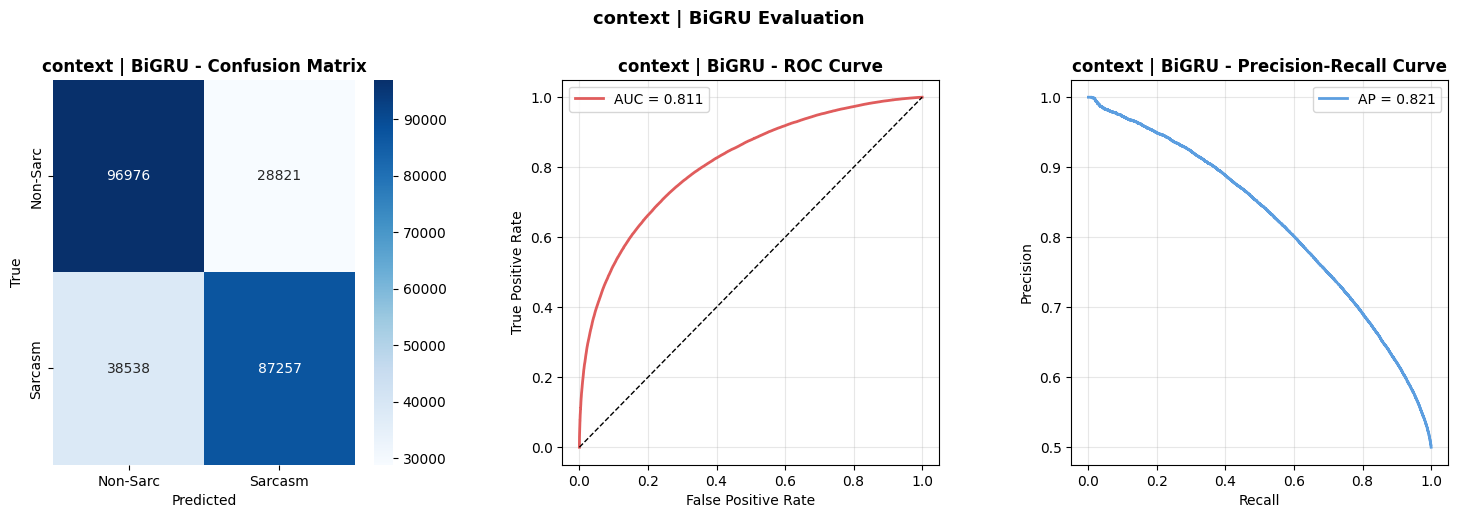

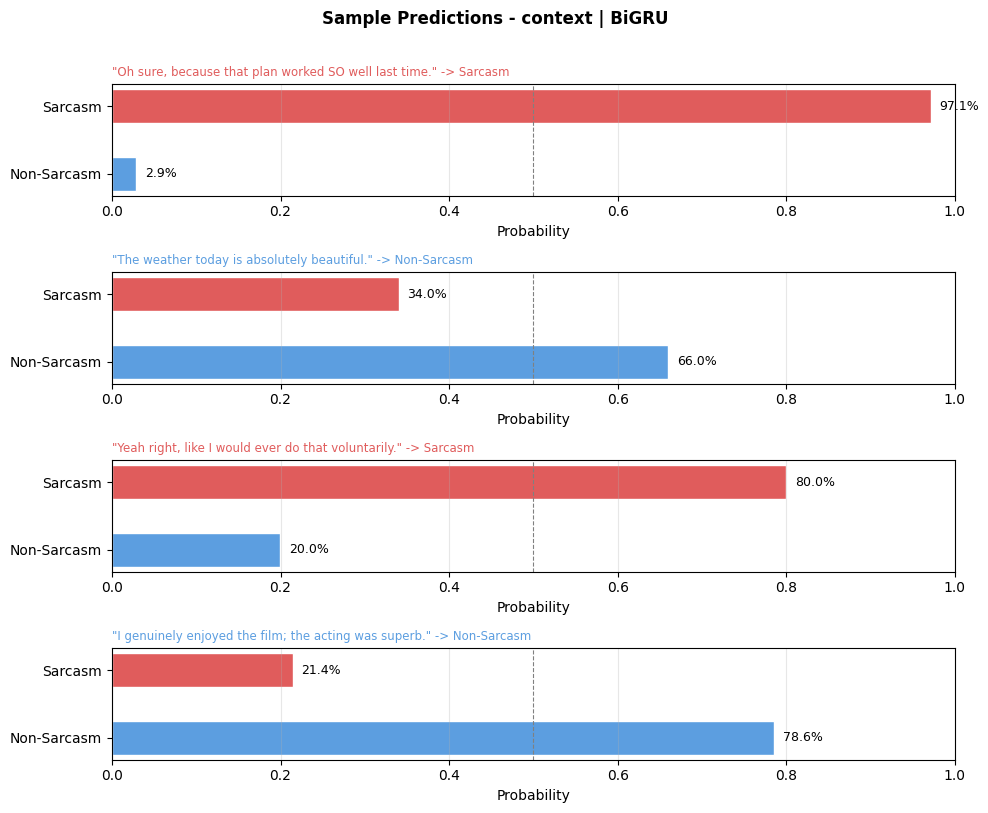

  0%|          | 0/983 [00:00<?, ?it/s]

  0%|          | 0/983 [00:00<?, ?it/s]


=== context | BiGRU+Attention ===
loss: 0.5786
acc: 0.7222
precision: 0.7237
recall: 0.7187
f1: 0.7212
roc_auc: 0.7948
avg_precision: 0.8013
Classification report:
              precision    recall  f1-score   support

           0     0.7206    0.7257    0.7231    125797
           1     0.7237    0.7187    0.7212    125795

    accuracy                         0.7222    251592
   macro avg     0.7222    0.7222    0.7222    251592
weighted avg     0.7222    0.7222    0.7222    251592

Confusion matrix:
[[91287 34510]
 [35390 90405]]


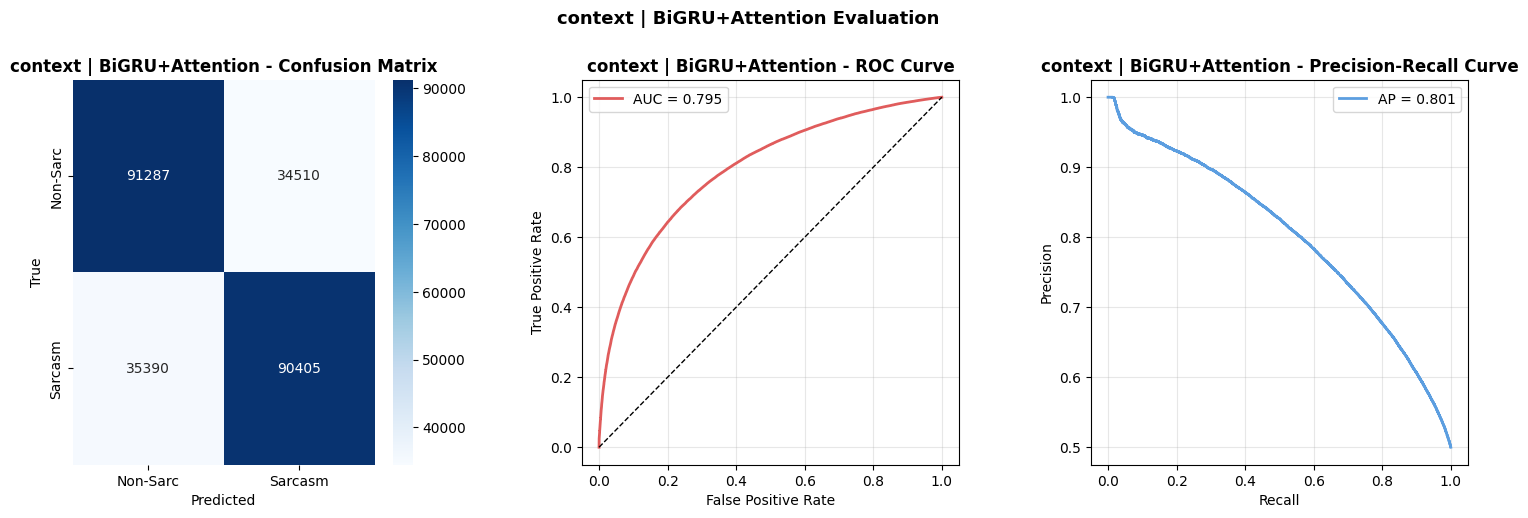

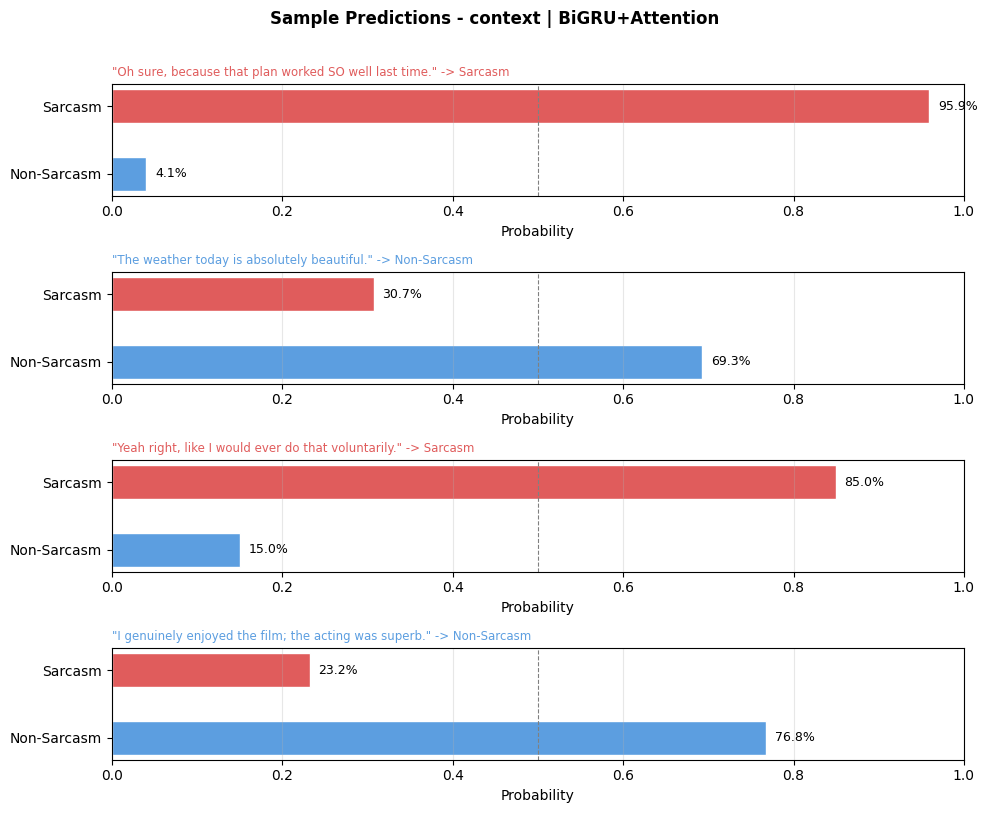

  0%|          | 0/983 [00:00<?, ?it/s]

  0%|          | 0/983 [00:00<?, ?it/s]


=== comment_only | BiGRU ===
loss: 0.5246
acc: 0.7356
precision: 0.7381
recall: 0.7305
f1: 0.7343
roc_auc: 0.8138
avg_precision: 0.8247
Classification report:
              precision    recall  f1-score   support

           0     0.7332    0.7408    0.7370    125797
           1     0.7381    0.7305    0.7343    125795

    accuracy                         0.7356    251592
   macro avg     0.7357    0.7356    0.7356    251592
weighted avg     0.7357    0.7356    0.7356    251592

Confusion matrix:
[[93196 32601]
 [33908 91887]]


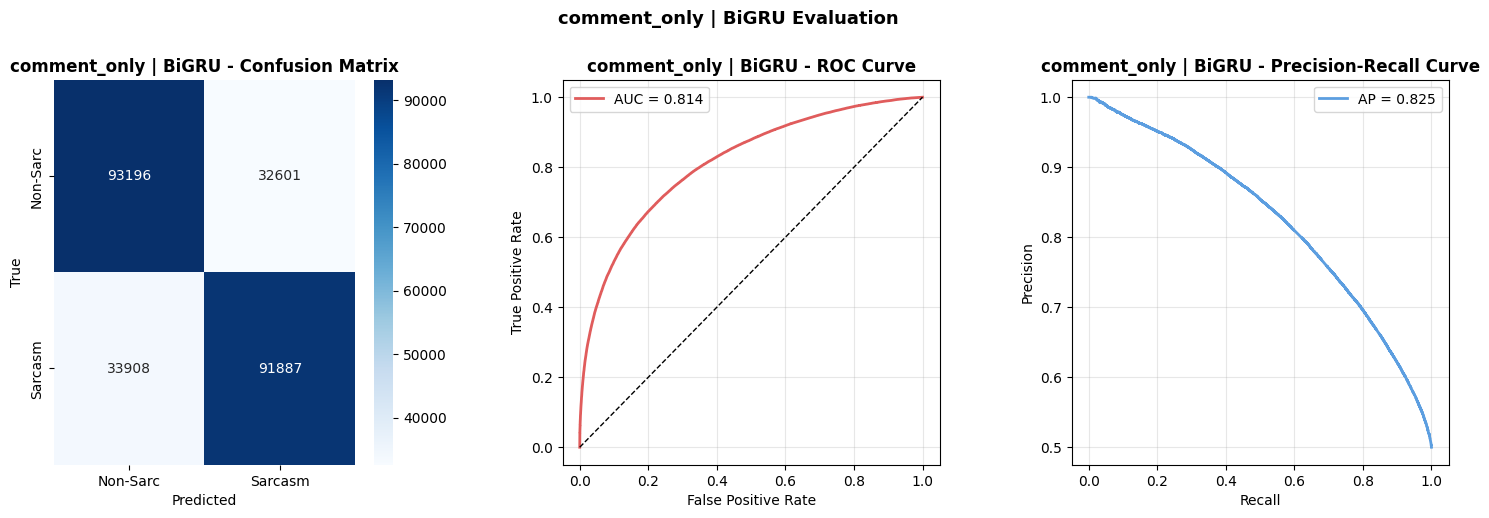

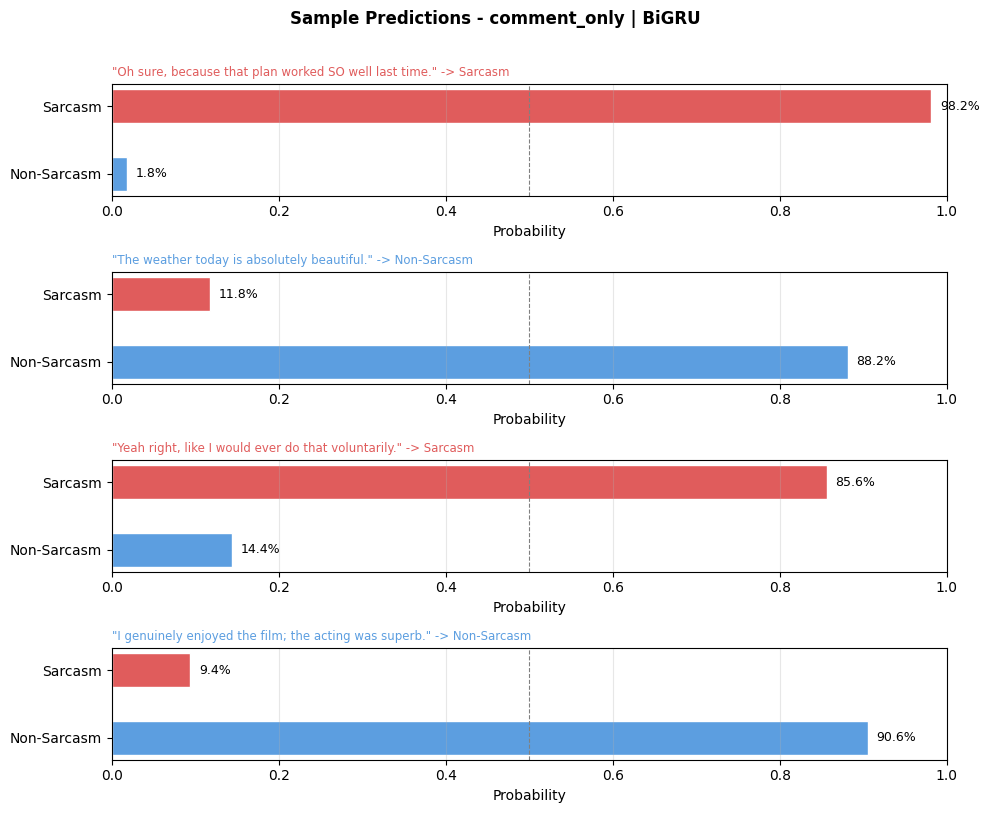

  0%|          | 0/983 [00:00<?, ?it/s]

  0%|          | 0/983 [00:00<?, ?it/s]


=== comment_only | BiGRU+Attention ===
loss: 0.5298
acc: 0.7384
precision: 0.7536
recall: 0.7086
f1: 0.7304
roc_auc: 0.8143
avg_precision: 0.8253
Classification report:
              precision    recall  f1-score   support

           0     0.7250    0.7683    0.7460    125797
           1     0.7536    0.7086    0.7304    125795

    accuracy                         0.7384    251592
   macro avg     0.7393    0.7384    0.7382    251592
weighted avg     0.7393    0.7384    0.7382    251592

Confusion matrix:
[[96646 29151]
 [36659 89136]]


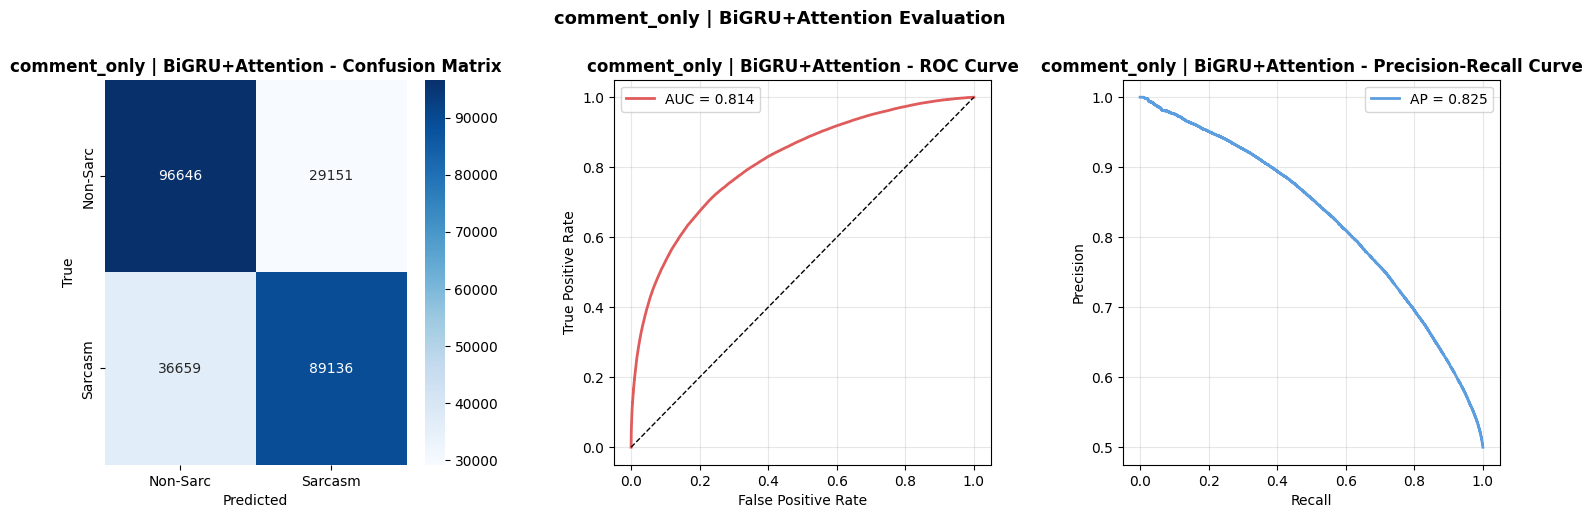

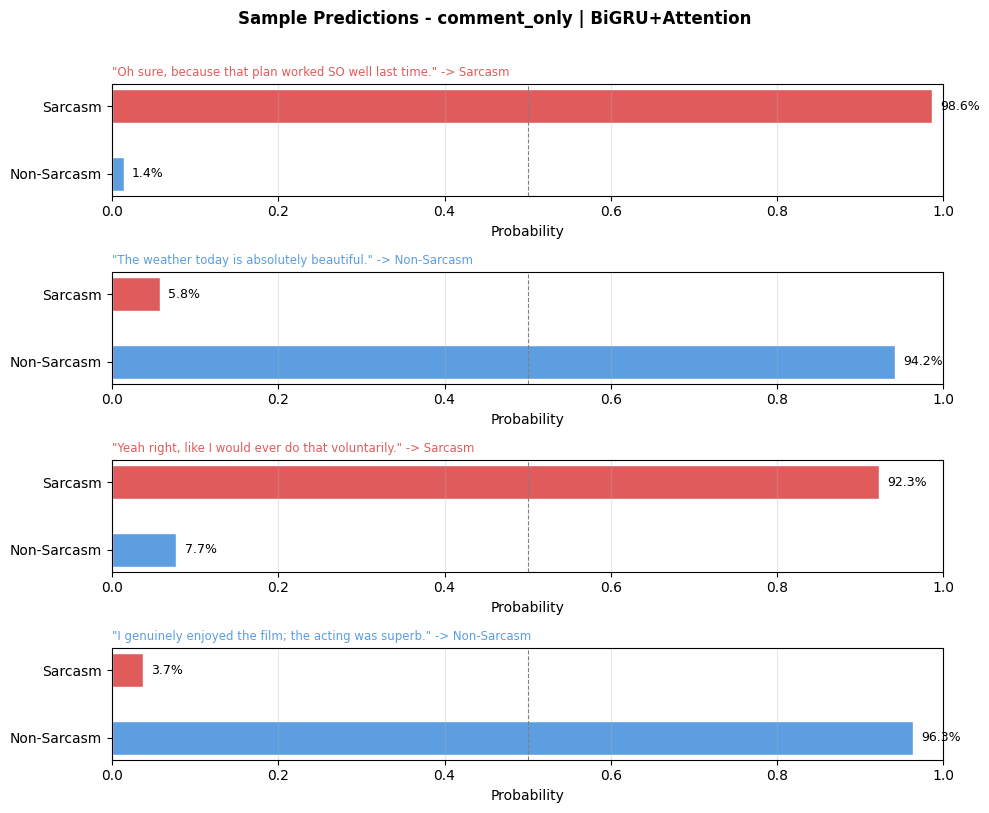

,acc,precision,recall,f1,roc_auc,avg_precision,model,input_mode,loss
0,0.735647,0.738119,0.730450,0.734265,0.813772,0.824713,BiGRU,comment_only,0.524635
1,0.738426,0.753557,0.708581,0.730377,0.814291,0.825298,BiGRU+Attention,comment_only,0.529836
2,0.732269,0.751710,0.693644,0.721511,0.810529,0.820738,BiGRU,context,0.533815
3,0.722169,0.723732,0.718669,0.721192,0.794826,0.801349,BiGRU+Attention,context,0.578646


Best model by test F1: comment_only | BiGRU


In [33]:
evaluation_rows = []
sample_comments = [
    "Oh sure, because that plan worked SO well last time.",
    "The weather today is absolutely beautiful.",
    "Yeah right, like I would ever do that voluntarily.",
    "I genuinely enjoyed the film; the acting was superb.",
]

for input_mode, model_runs in training_results.items():
    for model_name, model_result in model_runs.items():
        bundle = mode_bundles[input_mode]
        metrics, _, _ = evaluate_model(
            model_name,
            model_result,
            bundle["test_loader"],
            output_dir=model_result["model_dir"],
        )
        evaluation_rows.append(metrics)
        sample_results = visualize_predictions(model_name, model_result, sample_comments)
        save_json({"input_mode": input_mode, "model": model_name, "samples": sample_results}, Path(model_result["model_dir"]) / "sample_predictions.json")

evaluation_df = pd.DataFrame(evaluation_rows)
display(evaluation_df.sort_values(["input_mode", "f1"], ascending=[True, False]).reset_index(drop=True))

evaluation_df.to_csv(ARTIFACTS_ROOT / "evaluation_summary.csv", index=False)

best_row = evaluation_df.sort_values("f1", ascending=False).iloc[0]
print(f"Best model by test F1: {best_row['input_mode']} | {best_row['model']}")